In [11]:
!pip install anchor-exp -q

In [12]:
import matplotlib
import matplotlib.pyplot as plt
import math
import numpy as np
import time

In [13]:
!pip install --upgrade torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [14]:
import torch
import torchvision.models as models

# Φόρτωση Inception v3 με τα επίσημα προεκπαιδευμένα βάρη
model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.eval()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [15]:
if torch.cuda.is_available():
    model.to('cuda')

In [16]:
!wget https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
# Read the categories
with open("imagenet_classes.txt", "r") as f:
    class_names = [s.strip() for s in f.readlines()]

--2026-09-13 19:34:59--  https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10472 (10K) [text/plain]
Saving to: ‘imagenet_classes.txt.1’

imagenet_classes.tx 100%[===================>]  10.23K  --.-KB/s    in 0s      

2026-09-13 19:34:59 (104 MB/s) - ‘imagenet_classes.txt.1’ saved [10472/10472]



In [22]:
import numpy as np
import skimage.io
import skimage.transform
from skimage import color

def transform_img_fast(path):
    img = skimage.io.imread(path)
    if len(img.shape) != 3:
        img = color.gray2rgb(img)
    if img.shape[2] == 4:
        img = color.rgba2rgb(img)

    short_edge = min(img.shape[:2])
    yy = int((img.shape[0] - short_edge) / 2)
    xx = int((img.shape[1] - short_edge) / 2)
    crop_img = img[yy: yy + short_edge, xx: xx + short_edge]

    # Διαστάσεις 224x224 στο διάστημα [0, 1] για PyTorch torchvision μοντέλα
    return skimage.transform.resize(crop_img, (224, 224), mode='constant')

def transform_img_fn_fast(paths):
    out = []
    for i, path in enumerate(paths):
        if i % 100 == 0:
            print(i)
        out.append(transform_img_fast(path))
    return np.array(out)

In [23]:
import urllib
url, filename = ("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
try: urllib.URLopener().retrieve(url, filename)
except: urllib.request.urlretrieve(url, filename)

In [24]:
# def load_images(paths):
#     out = []
#     for path in paths:
#         input_image = Image.open(path)
#         tensor = preprocess(input_image).numpy()
#         out.append(tensor)
#     return out

In [25]:
#images = transform_img_fn_fast(['dog.jpg'])
images = transform_img_fn_fast(['nick.png'])

0


In [26]:
import torch
import torchvision.transforms as T

# Ορισμός του επίσημου ImageNet normalization για PyTorch torchvision
normalize = T.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

def predict(images):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.eval()  # Κλειδώνει Dropout και BatchNorm

    # 1. Μετατροπή διαστάσεων: (N, H, W, C) -> PyTorch (N, C, H, W)
    images = images.transpose((0, 3, 1, 2))

    # 2. Μετατροπή σε PyTorch Float Tensor
    input_tensor = torch.tensor(images, dtype=torch.float32)

    # 3. Εφαρμογή ImageNet Normalization και αποστολή στην GPU
    input_tensor = normalize(input_tensor).to(device)

    # 4. Απενεργοποίηση gradients για μέγιστη ταχύτητα
    with torch.no_grad():
        output = model(input_tensor)
        probabilities = torch.nn.functional.softmax(output, dim=1)

    return probabilities.cpu().numpy()

In [27]:
import copy
from skimage.segmentation import quickshift, mark_boundaries, slic, felzenszwalb
def ShowImageNoAxis(image, boundaries=None, save=None):
    fig = plt.figure()
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    if boundaries is not None:
        ax.imshow(mark_boundaries(image / 2 + 0.5, boundaries))
    else:
        ax.imshow(image / 2 + .5)
    if save is not None:
        plt.savefig(save)
    plt.show()

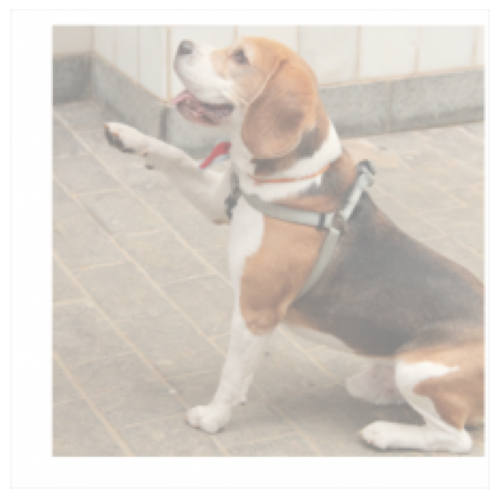

In [28]:
ShowImageNoAxis(images[0])

In [29]:
probs = predict(images)
idxs = np.argsort(-probs[0])
list(zip(probs[0][idxs[:5]], np.array(class_names)[idxs[:5]]))

[(np.float32(0.99997425), np.str_('beagle')),
 (np.float32(1.6295384e-05), np.str_('Walker hound')),
 (np.float32(8.935378e-06), np.str_('English foxhound')),
 (np.float32(3.735914e-07), np.str_('basset')),
 (np.float32(4.988592e-08), np.str_('bloodhound'))]

In [30]:
import anchor
import anchor.anchor_image

In [31]:
# 1. Δημιουργία της ακριβούς διαδρομής του αρχικού notebook
!mkdir -p /home/marcotcr/datasets/openimages/train

# 2. Λήψη ενός μικρού συνόλου εικόνων μέσα στον φάκελο
!wget -q https://github.com/EliSchwartz/imagenet-sample-images/archive/refs/heads/master.tar.gz -O /tmp/sample_images.tar.gz
!tar -xzf /tmp/sample_images.tar.gz -C /tmp/
!cp /tmp/imagenet-sample-images-master/*.JPEG /home/marcotcr/datasets/openimages/train/
!rm -rf /tmp/sample_images*

# 3. Έλεγχος ότι τα αρχεία υπάρχουν
!ls /home/marcotcr/datasets/openimages/train | head -n 5

n01440764_tench.JPEG
n01443537_goldfish.JPEG
n01484850_great_white_shark.JPEG
n01491361_tiger_shark.JPEG
n01494475_hammerhead.JPEG


In [32]:
import anchor
#/home/marcotcr/datasets/openimages/train contains a lot of arbitrary images - in this case, from openimages
explainer = anchor.anchor_image.AnchorImage(
    '/home/marcotcr/datasets/openimages/train/',
    transform_img_fn=transform_img_fn_fast,
    n=100
)

0


In [33]:
# segments, exp = explainer.explain_instance(images[0], predict, threshold=0.95, batch_size=50,                                            tau=0.20, verbose=True, min_shared_samples=200, beam_size=2)

# Οι υπερπαράμετροι αναζήτησης χαλάρωσαν (threshold, beam_size, min_shared_samples) ώστε να ευθυγραμμιστούν
# με το χαμηλότερο εμπειρικό precision της εικόνας (~68%) και να σταματήσει ο αλγόριθμος bandit να εκτελεί
# ατέρμονες επαναληπτικές κλήσεις στο βαθύ νευρωνικό δίκτυο.

segments, exp = explainer.explain_instance(
    images[0],
    predict,
    threshold=0.65,
    batch_size=100,
    tau=0.25,
    min_shared_samples=25,
    beam_size=1
)

True pred 162


In [34]:
exp

[(11, '', np.float64(0.1720813995001785), [], 0),
 (1, '', np.float64(0.5017985611510791), [], 0),
 (12, '', np.float64(0.671990171990172), [], 0)]

Anchor for prediction  beagle confidence 0.671990171990172


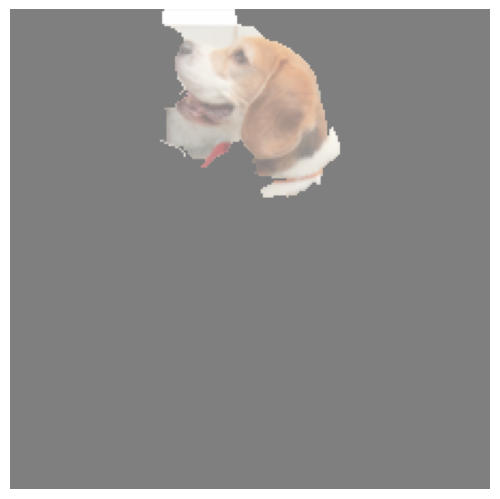

Counter Examples:


In [35]:
def show_exp(segments, exp, image, explainer):
    mask = np.ones(segments.shape).astype(bool)
    temp = copy.deepcopy(image)
    temp_img = copy.deepcopy(temp)
#     temp.img = temp.fudged_image.copy()
    temp[:] = 0
    # for x in exp_greedy[:3]:
    #     x = (x, x)
    for x in exp:
        temp[segments == x[0]] = temp_img[segments==x[0]]
    # temp.img[mask] = np.random.random(mask.nonzero()[0].shape[0] * 3).reshape(mask.nonzero()[0].shape[0], 3)
    print ('Anchor for prediction ', class_names[predict(np.expand_dims(image, 0))[0].argmax()], 'confidence', exp[-1][2])
    ShowImageNoAxis(temp)
    print('Counter Examples:')
    for e in exp[-1][3]:
        data = e[:-1]
        temp = explainer.dummys[e[-1]].copy()
        for x in data.nonzero()[0]:
            temp[segments == x] = image[segments == x]
        ShowImageNoAxis(temp)
        print('Prediction = ', names[predict_fn(np.expand_dims(temp, 0))[0].argmax()])
show_exp(segments, exp, images[0], explainer)

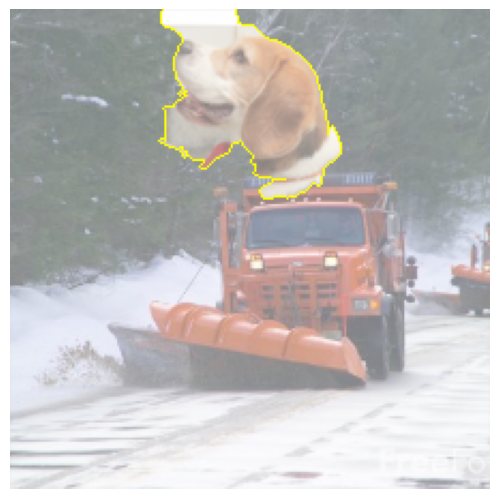

beagle 0.80083156


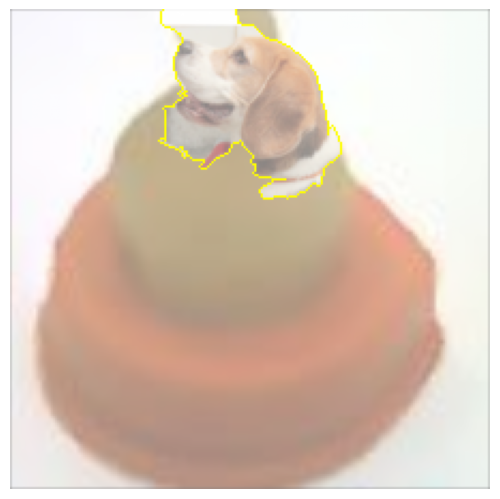

beagle 0.9995136


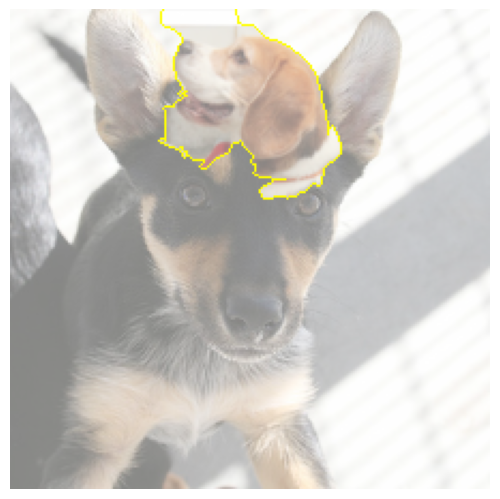

Cardigan 0.8427694


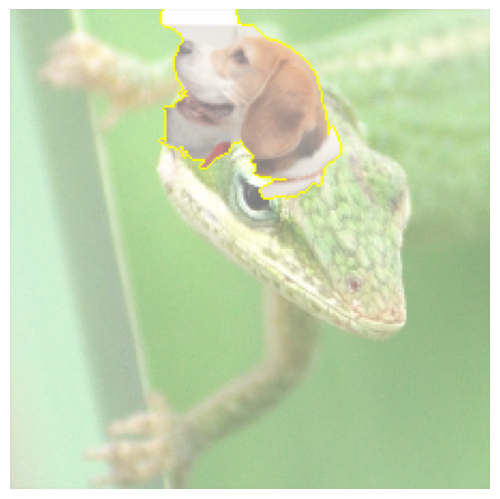

beagle 0.6027193


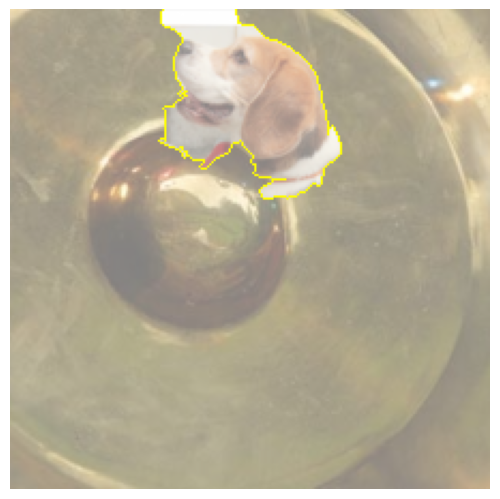

beagle 0.6618485


In [36]:
N = 5
chosen = np.random.choice(len(explainer.dummys), N)
imgs = []
masks = []
for c in chosen:
    temp = copy.deepcopy(explainer.dummys[c])
    mask = np.zeros(segments.shape).astype(bool)
    for f in exp:
        f = f[0]
        mask[segments == f] = 1
    temp[mask] = images[0][mask].copy()
    imgs.append(temp)
    masks.append(mask)
preds = predict(np.array(imgs))
for i, p in zip(imgs, preds):
#     if p.max() < 0.9:
#         continue
    ShowImageNoAxis(i, mask, '/tmp/nickz.png')
    print(class_names[p.argmax()], p.max())